In [51]:
from datasets import load_dataset

In [52]:
# Load the Hugging Face documentation dataset
dataset = load_dataset("m-ric/huggingface_doc", split="train")

print(f"Number of documents: {len(dataset)}")

Number of documents: 2647


In [53]:
# Inspect the dataset structure
print("Dataset features:")
print(dataset.features)

Dataset features:
{'text': Value('string'), 'source': Value('string')}


In [54]:
example = dataset[0]

print("Sample document:")
print("-" * 50)

for key,value in example.items():
    if isinstance(value, str) and len(value) > 1000:
        print(f"{key}: {value[:1500]}...")
    else:
        print(f"{key}: {value}")

Sample document:
--------------------------------------------------
text:  Create an Endpoint

After your first login, you will be directed to the [Endpoint creation page](https://ui.endpoints.huggingface.co/new). As an example, this guide will go through the steps to deploy [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) for text classification. 

## 1. Enter the Hugging Face Repository ID and your desired endpoint name:

<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_repository.png" alt="select repository" />

## 2. Select your Cloud Provider and region. Initially, only AWS will be available as a Cloud Provider with the `us-east-1` and `eu-west-1` regions. We will add Azure soon, and if you need to test Endpoints with other Cloud Providers or regions, please let us know.

<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/ass

In [55]:
pip install google-genai


In [57]:
import os
import getpass
from google import genai

# Securely input your Gemini API key (starts with AIza...)
os.environ["GEMINI_API_KEY"] = getpass.getpass("Enter your Gemini API key: ")

# Initialize the Gemini client (it automatically picks up GEMINI_API_KEY from os.environ)
client = genai.Client()




Enter your Gemini API key: ··········


In [ ]:
# Basic inference example using the free-tier model
response = client.models.generate_content(
    model='gemini-3.5-flash',
    contents='how can you help me?',
)

print(response.text)

In [58]:
response3 = client.models.generate_content(
    model='gemini-2.5-flash',
    contents='how can you help me with?'

)

print(response3.text)

I can help you with a wide variety of tasks and provide information across many domains. As a large language model, my primary function is to process and generate human-like text based on the prompts and questions you give me.

Here are some general categories of how I can help:

1.  **Information & Knowledge:**
    *   **Answering questions:** About facts, concepts, history, science, current events (up to my last training update), etc.
    *   **Explaining complex topics:** Breaking down difficult subjects into simpler terms.
    *   **Summarizing information:** Condensing long articles, documents, or conversations.
    *   **Providing definitions:** For words, phrases, or technical terms.

2.  **Content Creation & Writing:**
    *   **Drafting various texts:** Emails, letters, reports, essays, articles, blog posts, social media updates, marketing copy.
    *   **Generating creative content:** Stories, poems, scripts, song lyrics.
    *   **Brainstorming ideas:** For names, topics, pl

In [59]:
# A sample blog post about productivity
teaching_document = """
The Art of Deep Work: A Guide to Productivity

In today's world of constant notifications and endless distractions, the ability to focus deeply on cognitively demanding tasks has become increasingly rare—and increasingly valuable. This is what author Cal Newport calls "deep work": professional activities performed in a state of distraction-free concentration that push your cognitive capabilities to their limit.

Why Deep Work Matters

Deep work is valuable for several reasons. First, it allows you to produce high-quality output in less time. When you're fully concentrated on a single task, you work more efficiently and make fewer mistakes. Second, deep work helps you master complex skills faster. Learning difficult concepts requires sustained attention—something impossible to achieve when constantly switching between tasks.

Creating Your Deep Work Environment

The first step in cultivating deep work is designing an environment that supports concentration. This means more than just finding a quiet space. Consider your physical setup: Is your desk organized? Is the lighting appropriate? Do you have everything you need within reach?

Digital distractions are equally important to address. Turn off notifications on your devices. Close unnecessary browser tabs. Use website blockers if needed. The goal is to create a space where your attention isn't constantly being pulled away from the task at hand.

Time Blocking for Deep Work

Scheduling specific blocks of time for deep work is crucial. Don't wait for free time to magically appear—it won't. Instead, treat deep work sessions as important appointments with yourself. Many people find that early morning hours work best, when their mental energy is highest and distractions are minimal.

Start with manageable blocks. If you're new to deep work, even 60-90 minutes of focused time can feel challenging. As you build your concentration muscles, gradually extend these sessions. Some professionals work up to four-hour blocks of uninterrupted deep work.

The Shutdown Ritual

Just as important as starting deep work is knowing when to stop. Develop a shutdown ritual to mark the end of your workday. This might include reviewing your task list for tomorrow, closing all work-related browser tabs, and saying a specific phrase like "shutdown complete."

This ritual serves multiple purposes. It helps you mentally disconnect from work, reduces anxiety about unfinished tasks, and ensures you've captured anything important before stepping away. Without this clear boundary, work thoughts tend to linger into your evening, preventing true rest and recovery.

Measuring Your Progress

Track your deep work hours each week. This simple metric provides valuable feedback on your habits. You might discover that you're spending less time in deep work than you thought, or that certain days of the week are more conducive to concentration than others.

Remember, the goal isn't to spend every waking hour in deep work. Even the most focused professionals typically max out at four to five hours of truly deep work per day. What matters is consistency and intentionality—making deep work a regular part of your routine rather than an occasional occurrence.
"""

print(f"Document length: {len(teaching_document)} characters")
print(f"Number of paragraphs: {teaching_document.count(chr(10) + chr(10))}")

Document length: 3219 characters
Number of paragraphs: 15


---

## Strategy 1: Fixed-Size Token Chunking

### What Problem Does This Solve?

When you need **predictable, uniform chunk sizes** for consistent processing and embedding generation. This is the simplest and most common approach.

### What to Look For in the Visualization

Pay attention to:
- **All chunks (except the last one) are exactly the same size** in terms of tokens
- **Chunks may split in the middle of sentences or paragraphs** (see the color changes mid-sentence)
- **No overlap between chunks** means context from one chunk doesn't carry over to the next

In [60]:
!pip install -q chonkie[viz] rich

In [61]:
from chonkie import TokenChunker
from tokenizers import Tokenizer
from chonkie import Visualizer

In [62]:
from chonkie import TokenChunker
from tokenizers import Tokenizer
from chonkie import Visualizer

# Initialize the tokenizer
# We're using GPT-2's tokenizer as a standard reference
tokenizer = Tokenizer.from_pretrained("gpt2")

# Create a fixed-size chunker
# chunk_size: Each chunk will have exactly 128 tokens (except possibly the last one)
# chunk_overlap: 0 means no overlap - each chunk is completely independent
fixed_size_chunker = TokenChunker(
    tokenizer=tokenizer,
    chunk_size=128,
    chunk_overlap=0
)

# Apply chunking to our teaching document
fixed_chunks = fixed_size_chunker.chunk(teaching_document)

print(f"Number of chunks created: {len(fixed_chunks)}")
print(f"Chunk sizes (in tokens): {[chunk.token_count for chunk in fixed_chunks]}")

# Visualize the chunks
# Each color represents a different chunk
# Notice how the colors change abruptly, sometimes mid-sentence
viz = Visualizer()
viz.print(fixed_chunks)

Number of chunks created: 5
Chunk sizes (in tokens): [128, 128, 128, 128, 105]


The Art of Deep Work: A Guide to Productivity

In today's world of constant notifications and endless distractions, the ability to focus deeply on cognitively 
demanding tasks has become increasingly rare—and increasingly valuable. This is what author Cal Newport calls "deep
work": professional activities performed in a state of distraction-free concentration that push your cognitive 
capabilities to their limit.

Why Deep Work Matters

Deep work is valuable for several reasons. First, it allows you to produce high-quality output in less time. When 
you're fully concentrated on a single task, you work more efficiently and make fewer mistakes. Second, deep work 
helps you master complex skills faster. Learning difficult concepts requires sustained attention—something 
impossible to achieve when constantly switching between tasks.

Creating Your Deep Work Environment

The first step in cultivating deep work is designing an environment that supports concentration. This means more 
than just finding a quiet space. Consider your physical setup: Is your desk organized? Is the lighting appropriate?
Do you have everything you need within reach?

Digital distractions are equally important to address. Turn off notifications on your devices. Close unnecessary 
browser tabs. Use website blockers if needed. The goal is to create a space where your attention isn't constantly 
being pulled away from the task at hand.

Time Blocking for Deep Work

Scheduling specific blocks of time for deep work is crucial. Don't wait for free time to magically appear—it won't.
Instead, treat deep work sessions as important appointments with yourself. Many people find that early morning 
hours work best, when their mental energy is highest and distractions are minimal.

Start with manageable blocks. If you're new to deep work, even 60-90 minutes of focused time can feel challenging. 
As you build your concentration muscles, gradually extend these sessions. Some professionals work up to four-hour 
blocks of uninterrupted deep work.

The Shutdown Ritual

Just as important as starting deep work is knowing when to stop. Develop a shutdown ritual to mark the end of your 
workday. This might include reviewing your task list for tomorrow, closing all work-related browser tabs, and 
saying a specific phrase like "shutdown complete."

This ritual serves multiple purposes. It helps you mentally disconnect from work, reduces anxiety about unfinished 
tasks, and ensures you've captured anything important before stepping away. Without this clear boundary, work 
thoughts tend to linger into your evening, preventing true rest and recovery.

Measuring Your Progress

Track your deep work hours each week. This simple metric provides valuable feedback on your habits. You might 
discover that you're spending less time in deep work than you thought, or that certain days of the week are more 
conducive to concentration than others.

Remember, the goal isn't to spend every waking hour in deep work. Even the most focused professionals typically max
out at four to five hours of truly deep work per day. What matters is consistency and intentionality—making deep 
work a regular part of your routine rather than an occasional occurrence.

In [63]:
!pip install -q sentence-transformers

In [64]:
from sentence_transformers import SentenceTransformer

# Loading a pre-trained embedding model
# all-MiniLM-L6-v2 is lightweight and effective for general-purpose semantic search
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Model loaded: all-MiniLM-L6-v2")
print(f"Embedding dimension: {embedding_model.get_sentence_embedding_dimension()}")

# Create all_chunks by chunking all documents in the dataset
# Using TokenChunker for the full dataset
from chonkie import TokenChunker
from tokenizers import Tokenizer

# Initialize tokenizer and chunker
tokenizer = Tokenizer.from_pretrained("gpt2")
chunker = TokenChunker(
    tokenizer=tokenizer,
    chunk_size=256,
    chunk_overlap=32
)

# Chunk all documents in the dataset
all_chunks = []
for doc in dataset:
    doc_chunks = chunker.chunk(doc["text"])
    all_chunks.extend(doc_chunks)

print(f"Total chunks created from dataset: {len(all_chunks)}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded: all-MiniLM-L6-v2
Embedding dimension: 384


/tmp/ipykernel_621/1977533437.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding dimension: {embedding_model.get_sentence_embedding_dimension()}")


Total chunks created from dataset: 33769


In [65]:
all_chunks[880]

Chunk(text='          features: ['start', 'target', 'feat_static_cat', 'feat_dynamic_real', 'item_id'],
            num_rows: 862
        })
    })
```

Each example contains a few keys, of which `start` and `target` are the most important ones. Let us have a look at the first time series in the dataset:


```python
train_example = dataset["train"][0]
train_example.keys()

>>> dict_keys(['start', 'target', 'feat_static_cat', 'feat_dynamic_real', 'item_id'])
```

The `start` simply indicates the start of the time series (as a datetime), and the `target` contains the actual values of the time series.

The `start` will be useful to add time related features to the time series values, as extra input to the model (such as "month of year"). Since we know the frequency of the data is `hourly`, we know for', token_count=256, start_index=13598, end_index=14395)

In [66]:
example

{'text': ' Create an Endpoint\n\nAfter your first login, you will be directed to the [Endpoint creation page](https://ui.endpoints.huggingface.co/new). As an example, this guide will go through the steps to deploy [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) for text classification. \n\n## 1. Enter the Hugging Face Repository ID and your desired endpoint name:\n\n<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_repository.png" alt="select repository" />\n\n## 2. Select your Cloud Provider and region. Initially, only AWS will be available as a Cloud Provider with the `us-east-1` and `eu-west-1` regions. We will add Azure soon, and if you need to test Endpoints with other Cloud Providers or regions, please let us know.\n\n<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_region.png" alt="select region" />\n\n## 3. Defi

In [67]:
chunk_texts = [chunk.text for chunk in all_chunks]
print(f"Number of chunks to embed: {len(chunk_texts)}")
print(f"Sample chunk text (truncated): {chunk_texts[3][:2000]}...")


Number of chunks to embed: 33769
Sample chunk text (truncated):  Choosing a metric for your task

**So you've trained your model and want to see how well it’s doing on a dataset of your choice. Where do you start?**

There is no “one size fits all” approach to choosing an evaluation metric, but some good guidelines to keep in mind are:

## Categories of metrics

There are 3 high-level categories of metrics:

1. *Generic metrics*, which can be applied to a variety of situations and datasets, such as precision and accuracy.
2. *Task-specific metrics*, which are limited to a given task, such as Machine Translation (often evaluated using metrics [BLEU](https://huggingface.co/metrics/bleu) or [ROUGE](https://huggingface.co/metrics/rouge)) or Named Entity Recognition (often evaluated with [seqeval](https://huggingface.co/metrics/seqeval)).
3. *Dataset-specific metrics*, which aim to measure model performance on specific benchmarks: for instance, the [GLUE benchmark](https://huggingface.co/da

In [70]:
embeddings = embedding_model.encode(chunk_texts[0:33769])
print(f"Embeddings shape: {embeddings.shape}")
print(f"Each chunk is represented by a {embeddings.shape[1]}-dimensional vector")

Embeddings shape: (33769, 384)
Each chunk is represented by a 384-dimensional vector


In [71]:
# Embed a sample query using the same model
sample_query = "How do I load a pretrained model?"
query_embedding = embedding_model.encode(sample_query)

print(f"Query: '{sample_query}'")
print(f"Query embedding shape: {query_embedding.shape}")
print(f"Query embedding (first 10 values): {query_embedding[:10]}")

Query: 'How do I load a pretrained model?'
Query embedding shape: (384,)
Query embedding (first 10 values): [-0.02789503 -0.04522779  0.00200946  0.0494822  -0.01643987  0.08898935
 -0.08490767  0.04477693 -0.05589386 -0.04211756]


In [72]:
!pip install -q chromadb

In [74]:
import chromadb
from chromadb.utils import embedding_functions
client = chromadb.Client()
collection = client.get_or_create_collection(name="huggingface_docs",
                                      metadata={"description": "Hugging Face documentation chunks"})

---

### **Adding Documents to the Collection**

Now we'll add our chunked documents to the collection. ChromaDB will automatically handle the embedding generation if we don't provide embeddings explicitly, but since we've already generated embeddings, we'll use those.

In [77]:
num_docs_to_add = len(chunk_texts)
ids = [f"doc_{i}" for i in range(num_docs_to_add)]

batch_size = 5000  # Set a batch size smaller than ChromaDB's max limit of 5461

for i in range(0, num_docs_to_add, batch_size):
    batch_ids = ids[i:i + batch_size]
    batch_documents = chunk_texts[i:i + batch_size]
    batch_embeddings = embeddings[i:i + batch_size].tolist()

    print(f"Adding batch {i//batch_size + 1}/{(num_docs_to_add + batch_size - 1)//batch_size} ({len(batch_ids)} documents)... ")
    collection.add(
        ids=batch_ids,
        documents=batch_documents,
        embeddings=batch_embeddings
    )
    print(f"Batch added. Total documents in collection: {collection.count()}")

print(f"\nFinished adding {num_docs_to_add} documents to the collection.")
print(f"Final collection count: {collection.count()} documents")

Adding batch 1/7 (5000 documents)... 
Batch added. Total documents in collection: 5000
Adding batch 2/7 (5000 documents)... 
Batch added. Total documents in collection: 10000
Adding batch 3/7 (5000 documents)... 
Batch added. Total documents in collection: 15000
Adding batch 4/7 (5000 documents)... 
Batch added. Total documents in collection: 20000
Adding batch 5/7 (5000 documents)... 
Batch added. Total documents in collection: 25000
Adding batch 6/7 (5000 documents)... 
Batch added. Total documents in collection: 30000
Adding batch 7/7 (3769 documents)... 
Batch added. Total documents in collection: 33769

Finished adding 33769 documents to the collection.
Final collection count: 33769 documents


### Key Differences Summarized:

| Feature            | `all-MiniLM-L6-v2` (Sentence Transformer) | BERT (Base/Large)                            | OpenAI Embeddings                         |
| :----------------- | :---------------------------------------- | :------------------------------------------- | :---------------------------------------- |
| **Primary Use**    | Semantic similarity, sentence comparison  | Contextual understanding, fine-tuning        | Semantic similarity, general-purpose      |
| **Output**         | Single sentence embedding                 | Token embeddings (requires pooling for sentences) | Single embedding per input text           |
| **Size/Speed**     | Lightweight, fast, efficient              | Larger, slower for direct similarity         | API-based, high performance, cost-per-token |
| **Training**       | Siamese/Triplet for similarity            | MLM, NSP for language understanding          | Proprietary, large-scale, diverse         |
| **Access**         | Open-source, local inference              | Open-source, local inference                 | API access, proprietary                   |
| **Best for...**    | Real-time search, clustering, local apps  | Fine-tuning, NLP tasks (NER, QA)             | SOTA semantic search, complex RAG         |

### When to use BERT embeddings:

1.  **Fine-tuning for Downstream NLP Tasks:**
    *   **Text Classification (e.g., sentiment analysis, spam detection):** BERT's rich contextual understanding of words allows it to learn nuanced features for classifying entire documents or sentences more effectively than generic embeddings if you fine-tune it on your specific dataset.
    *   **Named Entity Recognition (NER):** Since BERT provides a contextual embedding for *each token*, it's ideal for tasks where you need to identify and classify specific entities (like names, locations, organizations) within text.
    *   **Question Answering (QA):** For tasks like extractive QA (where the answer is a span of text in the document), BERT's token-level representations are crucial for pinpointing the exact answer.
    *   **Summarization (Extractive):** Similarly, for extractive summarization, where you select important sentences from a document, BERT's ability to understand the importance of individual sentences within the larger context can be highly beneficial.

2.  **Tasks Requiring Deep Contextual Understanding:**
    *   **Disambiguation:** When a word has multiple meanings depending on context (e.g., 'bank' as a financial institution vs. a river bank), BERT's bidirectional nature allows it to better disambiguate meaning based on surrounding words.
    *   **Paraphrase Generation/Detection:** Understanding subtle semantic shifts and maintaining core meaning is a strength of BERT's deep contextual representations.

3.  **When Computational Resources (and Time) are Not a Primary Constraint:**
    *   If you have the computational power and don't need real-time embedding generation for massive datasets, BERT can provide superior representations for tasks where accuracy is paramount, even if it's slower than `all-MiniLM-L6-v2` for generating sentence embeddings.

### When to use `all-MiniLM-L6-v2` (Sentence Transformer) embeddings:

1.  **Semantic Search and Information Retrieval:**
    *   When you need to find documents or passages that are semantically similar to a given query, `all-MiniLM-L6-v2` is highly effective. It's specifically trained to produce embeddings where texts with similar meanings are close together in vector space.

2.  **Clustering and Grouping Texts:**
    *   For tasks like grouping similar news articles, customer reviews, or forum posts, these embeddings allow you to cluster texts based on their semantic content efficiently.

3.  **Duplicate Detection:**
    *   Identifying near-duplicate documents or paraphrases is straightforward by comparing their `all-MiniLM-L6-v2` embeddings.

4.  **Recommendation Systems:**
    *   Suggesting similar products, articles, or content based on a user's past interactions or current query. The efficiency and quality of these embeddings make them suitable for large-scale recommendation engines.

5.  **Efficiency and Speed:**
    *   `all-MiniLM-L6-v2` is a lightweight model, making it very fast for generating embeddings, especially for real-time applications or when processing large volumes of text on less powerful hardware. It's ideal when you need good performance without the computational overhead of larger models.

6.  **Offline or Local Deployment:**
    *   Since it's a relatively small model, it can be easily deployed and run locally or on edge devices without requiring constant API calls or significant cloud resources.

7.  **General-Purpose Embeddings for Similarity:**
    *   If your primary goal is to represent sentences or short paragraphs as vectors that can be directly used for similarity comparisons (e.g., cosine similarity), `all-MiniLM-L6-v2` is an excellent choice as it's directly optimized for this.

In essence, if your application heavily relies on comparing the *meaning* of different pieces of text quickly and efficiently, `all-MiniLM-L6-v2` provides a strong balance of performance, accuracy, and resource efficiency.

---

### **Semantic Search: Querying the Vector Database**

The power of vector databases lies in semantic search—finding documents based on meaning rather than exact keyword matches. Let's see this in action.

In [78]:
help(collection.query)

Help on method query in module chromadb.api.models.Collection:

query(query_embeddings: Union[numpy.ndarray[Any, numpy.dtype[Union[numpy.int32, numpy.float32]]], List[numpy.ndarray[Any, numpy.dtype[Union[numpy.int32, numpy.float32]]]], Sequence[float], Sequence[int], List[Union[Sequence[float], Sequence[int]]], NoneType] = None, query_texts: Union[str, List[str], NoneType] = None, query_images: Union[numpy.ndarray[Any, numpy.dtype[Union[numpy.uint64, numpy.int64, numpy.float64]]], List[numpy.ndarray[Any, numpy.dtype[Union[numpy.uint64, numpy.int64, numpy.float64]]]], NoneType] = None, query_uris: Union[str, List[str], NoneType] = None, ids: Union[str, List[str], NoneType] = None, n_results: int = 10, where: Optional[Dict[Union[str, Literal['$and'], Literal['$or']], Union[str, int, float, bool, Dict[Union[Literal['$gt'], Literal['$gte'], Literal['$lt'], Literal['$lte'], Literal['$ne'], Literal['$eq'], Literal['$and'], Literal['$or']], Union[str, int, float, bool]], Dict[Union[Literal['$

In [79]:
# Query the collection
user_query = "How do I load a pretrained model?"

# Perform similarity search
# ChromaDB will embed the query using the same method and find closest matches
results = collection.query(
    query_texts=[user_query],
    n_results=3  # Return top 3 most similar chunks
)

print(f"Query: '{user_query}'\n")
print("="*80)
print("Most Relevant Results:\n")

Query: 'How do I load a pretrained model?'

Most Relevant Results:



In [80]:
for i, (doc, distance) in enumerate(zip(results['documents'][0], results['distances'][0]), 1):
    print(f"Result {i} (Distance: {distance:.4f}):")
    print(f"{doc[:300]}...")  # Print first 300 characters
    print("-"*80)

Result 1 (Distance: 0.7207):
 the from_pretrained method. We just have to use the identifier from the hub and we can see that the model configuration and weights are automatically downloaded. We can use this model as we would any other Transformers model, for instance by loading it in a pipeline. Try the push_to_hub API on your...
--------------------------------------------------------------------------------
Result 2 (Distance: 0.7463):
models and everyone can load it using `AutoModel.from_pretrained("username/model_name")`.

[![tb](assets/01_how-to-train/model_page.png)](https://huggingface.co/julien-c/EsperBERTo-small)


If you want to take a look at models in different languages, check https://huggingface.co/models

[![all model...
--------------------------------------------------------------------------------
Result 3 (Distance: 0.7910):
```
{/if}

<Tip>
When using a pretrained model, make sure to check how it was trained, on which datasets, its limits, and its biases. All of th

**What's happening here:**
1. ChromaDB converts your query text into an embedding vector using the same embedding model
2. It calculates the similarity (using cosine similarity or dot product) between the query vector and all stored document vectors
3. It returns the top N most similar chunks

The "distance" metric indicates how close the query is to each result—lower values mean higher similarity.

---

### **Understanding Metadata: Adding Structure to Semantic Search**

Beyond just text and embeddings, we can attach **metadata** to each chunk—structured information like source document, section title, timestamp, or any other relevant attributes.

In [82]:
# Let's recreate our collection with metadata
client.delete_collection(name="huggingface_docs")

collection = client.create_collection(
    name="huggingface_docs",
    metadata={"description": "Hugging Face documentation with metadata"}
)

# Add documents with metadata
# For this example, we'll add simple metadata indicating the chunk index
metadatas = [{"chunk_index": i, "source": "huggingface_doc"} for i in range(num_docs_to_add)]

batch_size = 5000  # Use the same batch size as before

for i in range(0, num_docs_to_add, batch_size):
    batch_ids = ids[i:i + batch_size]
    batch_documents = chunk_texts[i:i + batch_size]
    batch_embeddings = embeddings[i:i + batch_size].tolist()
    batch_metadatas = metadatas[i:i + batch_size]

    print(f"Adding batch {i//batch_size + 1}/{(num_docs_to_add + batch_size - 1)//batch_size} ({len(batch_ids)} documents) with metadata...")
    collection.add(
        ids=batch_ids,
        documents=batch_documents,
        embeddings=batch_embeddings,
        metadatas=batch_metadatas
    )
    print(f"Batch added. Total documents in collection: {collection.count()}")

print(f"\nFinished adding {num_docs_to_add} documents with metadata to the collection.")
print(f"Final collection count: {collection.count()} documents")

Adding batch 1/7 (5000 documents) with metadata...
Batch added. Total documents in collection: 5000
Adding batch 2/7 (5000 documents) with metadata...
Batch added. Total documents in collection: 10000
Adding batch 3/7 (5000 documents) with metadata...
Batch added. Total documents in collection: 15000
Adding batch 4/7 (5000 documents) with metadata...
Batch added. Total documents in collection: 20000
Adding batch 5/7 (5000 documents) with metadata...
Batch added. Total documents in collection: 25000
Adding batch 6/7 (5000 documents) with metadata...
Batch added. Total documents in collection: 30000
Adding batch 7/7 (3769 documents) with metadata...
Batch added. Total documents in collection: 33769

Finished adding 33769 documents with metadata to the collection.
Final collection count: 33769 documents


---

### **Filtered Semantic Search**

Metadata becomes powerful when combined with semantic search. You can perform **filtered queries**—for example, "find similar documents, but only from a specific source or time period."

In [83]:
# Query with metadata filtering
filtered_results = collection.query(
    query_texts=["loading models"],
    n_results=3,
    where={"chunk_index": {"$gte": 50}}  # Only search chunks from index 50 onwards
)

print("Filtered Query Results (chunk_index >= 50):")
print("="*80)
for i, (doc, metadata) in enumerate(zip(filtered_results['documents'][0],
                                         filtered_results['metadatas'][0]), 1):
    print(f"Result {i} (Chunk Index: {metadata['chunk_index']}):")
    print(f"{doc[:200]}...")
    print("-"*80)

Filtered Query Results (chunk_index >= 50):
Result 1 (Chunk Index: 9906):
models and everyone can load it using `AutoModel.from_pretrained("username/model_name")`.

[![tb](assets/01_how-to-train/model_page.png)](https://huggingface.co/julien-c/EsperBERTo-small)


If you wan...
--------------------------------------------------------------------------------
Result 2 (Chunk Index: 23458):
model-cards) and any other relevant information
   or data necessary to run the model (for example, training logs). This method is often called `push_to_hub()`.
2. **Download from Hub:** implement a m...
--------------------------------------------------------------------------------
Result 3 (Chunk Index: 10594):
 to `load` an app hosted on
[Hugging Face Spaces](https://huggingface.co/spaces) prior to treating it like a function in your own app.
You can also load models hosted on the [Hugging Face Model Hub](h...
--------------------------------------------------------------------------------


---

### **Key Takeaways**

We've now completed the foundational retrieval pipeline:

1. **Chunked documents** into semantically coherent pieces
2. **Generated embeddings** for each chunk using a transformer model
3. **Stored chunks and embeddings** in a vector database (ChromaDB)
4. **Performed semantic search** to retrieve relevant chunks based on meaning
5. **Used metadata filtering** to refine search results

In a production RAG system, the next step would be to take these retrieved chunks and pass them as context to a large language model to generate informed, grounded responses to user queries.

---

---

## **Advanced Retrieval: Scaling to Production**

You've successfully built a vector database and implemented semantic search. Your system can find relevant documents based on **meaning**, not just keywords. But as your knowledge base scales to millions of documents, you hit two critical challenges:

1. **Speed**: How do you search through millions of vectors quickly without checking every single one?

2. **Precision**: How do you make sure the documents you retrieve are truly the *best* matches, not just decent ones?

Think about Google—they search billions of web pages in milliseconds and almost always show you what you're looking for in the first few results. They use sophisticated techniques to achieve this.

---

## **Challenge 1: Searching Millions of Vectors**

Let's start with a fundamental problem. Imagine you have **10 million document chunks** in your vector database. Each chunk is represented by a **768-dimensional vector** (the dimension from our embedding model). A user asks a question, and you need to find the most similar vectors.

### **The Brute Force Approach (and Why It Fails)**

The naive approach is a **brute force search**: calculate the similarity between the query vector and every single document vector, then sort to find the top matches.

For a 768-dimensional vector, each similarity calculation involves **768 multiplications and additions**.

With 10 million documents:

- **10 million × 768 operations = 7.68 billion operations per query**
- This takes **seconds per query**, which is unacceptable for production systems

Users expect results in **milliseconds**, not seconds. We need a smarter approach.

---

### **The Solution: Approximate Nearest Neighbor (ANN) with HNSW**

You don't need to find the *perfect* nearest neighbors—you need to find **good enough neighbors really fast**.

This trade-off between speed and accuracy is called **Approximate Nearest Neighbor search (ANN)**.

The most popular algorithm for this is **HNSW (Hierarchical Navigable Small World)**, which is used by **ChromaDB, Pinecone, Weaviate**, and most modern vector databases.

---

### **Understanding HNSW: The Search Process**

HNSW builds a multi-layer graph structure where:
- **Top layers** have sparse, long-range connections (like highways between cities)
- **Bottom layers** have dense, local connections (like streets within a neighborhood)

When a search begins, here's what happens:

**Query**: *"How do I reset my password?"*

1. **Top layer (Layer 3)**  
   Start at a random hub point. Jump to the hub point that's directionally closer to the query.  
   *(Just ~2 comparisons)*

2. **Layer 2**  
   Now in the right *region* of the space. Check connections to find closer points.  
   *(Maybe 5–10 comparisons)*

3. **Layer 1**  
   Getting close. Refine position by checking local connections.  
   *(Maybe 20–30 comparisons)*

4. **Layer 0 (bottom)**  
   Very close now. Do a detailed search of immediate neighbors to find the top matches.  
   *(Maybe 50–100 comparisons)*

**Total**: ~**100–150 comparisons instead of 10 million!**

---

### **Why This Works**

**Similar vectors tend to be clustered together** in the vector space. Once you navigate to the right neighborhood at the higher layers, you only need to search locally at the bottom layer.

This gives you **logarithmic search time** instead of linear:

- **Brute force**: `O(n)` — time grows linearly with data size  
- **HNSW**: `O(log n)` — time grows logarithmically with data size  

In practice, this means:

- **1 million documents**: ~20 hops instead of 1 million comparisons  
- **10 million documents**: ~23 hops instead of 10 million comparisons  
- **100 million documents**: ~27 hops instead of 100 million comparisons  

ChromaDB uses HNSW by default, which is why our searches are fast even with thousands of documents!

---

## **Setting Up Production-Grade Vector Store with LangChain**

Let's rebuild our vector database using LangChain and ChromaDB following Hugging Face best practices. This will give us better integration with advanced retrieval techniques.

In [84]:
# Install required libraries with correct versions
!pip install -q langchain langchain-community langchain-huggingface chromadb ragatouille

In [85]:
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import filter_complex_metadata

# Use the BAAI/bge-base-en-v1.5 model - a strong bi-encoder for retrieval
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-base-en-v1.5")

print(f"Embedding model loaded: BAAI/bge-base-en-v1.5")
print(f"This is a bi-encoder that processes queries and documents independently")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding model loaded: BAAI/bge-base-en-v1.5
This is a bi-encoder that processes queries and documents independently


Earlier in the notebook, we used `all-MiniLM-L6-v2` as our embedding model.

This change to `BAAI/bge-base-en-v1.5` is part of transitioning to a more **'production-grade' vector store setup** using LangChain, as indicated by the markdown sections right before this code block. While `all-MiniLM-L6-v2` is a good, lightweight general-purpose model, `BAAI/bge-base-en-v1.5` (or similar models from the BGE family) is often considered a stronger, more specialized **bi-encoder** for retrieval tasks.

Here's why we're making this switch:

*   **Performance:** BGE models generally offer superior performance for semantic search and retrieval compared to MiniLM models, especially for more nuanced or complex queries.
*   **LangChain Integration:** This new setup uses LangChain, which often integrates well with these more advanced embedding models for building robust RAG (Retrieval Augmented Generation) systems.
*   **Best Practices:** This part of the notebook focuses on 'Advanced Retrieval' and 'Setting Up Production-Grade Vector Store with LangChain,' which often involves using state-of-the-art embedding models for better accuracy and relevance in real-world scenarios.

So, it's an upgrade to enhance the quality of our embeddings for the advanced retrieval pipeline we're building!

In [86]:
# Prepare documents for ChromaDB
# We'll use the chunks we created earlier
from langchain_core.documents import Document

# Convert our chunks to LangChain Document objects
documents = []
for i,chunk_texts in enumerate(chunk_texts[:200]):
    metadata = {"chunk_index": i, "source": "huggingface_doc"}
    documents.append(Document(page_content=chunk_texts, metadata=metadata))

# ChromaDB doesn't support complex metadata, so filter it
docs = filter_complex_metadata(documents)

print(f"Prepared {len(docs)} documents for indexing")

Prepared 200 documents for indexing


In [87]:
# Create ChromaDB vector store with HNSW indexing
# ChromaDB automatically uses HNSW for efficient similarity search
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embeddings,
    collection_name="huggingface_docs_advanced"
)

print("Vector store created with HNSW indexing")
print(f"Total documents indexed: {vectorstore._collection.count()}")

Vector store created with HNSW indexing
Total documents indexed: 400


In [88]:
# Create a retriever - this uses the bi-encoder for fast initial search
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 20}  # Retrieve top 20 candidates initially
)

print("Retriever configured:")
print("  - Search type: similarity (cosine distance)")
print("  - Initial candidates: 20")
print("  - Algorithm: HNSW (logarithmic search time)")

Retriever configured:
  - Search type: similarity (cosine distance)
  - Initial candidates: 20
  - Algorithm: HNSW (logarithmic search time)


---

## **Challenge 2: The Semantic Gap**

Even with fast search, there's another problem: **the semantic gap** between queries and documents.

### **The Problem**

Users ask short, simple questions:

- *"caffeine effects on teens"*  
- *"best practices for error handling"*  
- *"How do I load a pretrained model?"*  

But the documents containing answers are long and descriptive:

- *"A comprehensive 2022 longitudinal study investigated the impact of daily stimulant consumption patterns among adolescent populations aged 13–17..."*

- *"When implementing production-grade software systems, developers must consider multiple approaches to exception management, including try-catch blocks, error boundaries, and..."*

- *"The AutoModelForSequenceClassification class provides a convenient interface for loading pre-trained transformer models with task-specific heads. To initialize a model, you can use the from_pretrained() method..."*

The query and document use **completely different vocabulary and writing styles**. Their vectors may not be as similar as they should be, leading to **poor retrieval results**.

---

### **The Solution: HyDE (Hypothetical Document Embeddings)**

**HyDE** is a clever technique that bridges the semantic gap. Instead of searching with the user's query directly, you:

1. **Ask an LLM to generate a hypothetical answer** to the question  
2. **Embed this generated answer** (which is now document-like)  
3. **Search using the generated answer's vector**

The LLM generates text that's stylistically similar to the documents in your database—longer, more detailed, using similar vocabulary and structure.

---

### **Implementing HyDE with GPT**

In [89]:
import os
import google.generativeai as genai

# Configure the global API key before calling models
genai.configure(api_key=os.environ.get("GEMINI_API_KEY"))

def generate_hypothetical_document(query):
    """
    Generate a hypothetical document that answers the query.
    This document will be stylistically similar to actual documentation.
    """
    # System instructions and generation parameters are passed directly to GenerativeModel
    model = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction="You are a technical documentation writer for Hugging Face. Generate a detailed, technical answer in the style of official documentation."
    )

    # Config options go into a plain dictionary for generation_config
    response = model.generate_content(
        contents=f"Write a comprehensive, multi-paragraph technical documentation-style answer to the question: {query}",
        generation_config={
            "max_output_tokens": 1024, # Increased max_output_tokens significantly
            "temperature": 0.7,
        }
    )

    return response.text

def hyde_search(query, retriever):
    """
    Perform HyDE-enhanced search.
    """
    # Generate hypothetical document
    hypothetical_doc = generate_hypothetical_document(query)

    # Search using the hypothetical document instead of the query
    results = retriever.invoke(hypothetical_doc)

    return results, hypothetical_doc

In [90]:
# Compare standard search vs HyDE
test_query = "How do I load a pretrained model?"

print("=" * 80)
print("COMPARISON: STANDARD SEARCH vs HyDE")
print("=" * 80)
print(f"\nOriginal Query: '{test_query}'\n")

# Standard search
print("-" * 80)
print("STANDARD SEARCH (using original query)")
print("-" * 80)
standard_results = retriever.invoke(test_query)

for i, doc in enumerate(standard_results[:3], 1):
    print(f"\nResult {i}:")
    print(f"{doc.page_content[:500]}...")

# HyDE search
print("\n" + "=" * 80)
print("HyDE SEARCH (using generated hypothetical document)")
print("=" * 80)


hyde_results, hypothetical_doc = hyde_search(test_query, retriever)

print(f"\nGenerated Hypothetical Document:")
print(f"{hypothetical_doc}\n")
print("-" * 80)

for i, doc in enumerate(hyde_results[:3], 1):
    print(f"\nResult {i}:")
    print(f"{doc.page_content[:1000]}...")


COMPARISON: STANDARD SEARCH vs HyDE

Original Query: 'How do I load a pretrained model?'

--------------------------------------------------------------------------------
STANDARD SEARCH (using original query)
--------------------------------------------------------------------------------

Result 1:
://github.com/rwightman/pytorch-image-models/blob/master/train.py) to use your dataset.

## How do I train this model?

You can follow the [timm recipe scripts](../scripts) for training a new model afresh.

## Citation

```BibTeX
@misc{hu2019squeezeandexcitation,
      title={Squeeze-and-Excitation Networks}, 
      author={Jie Hu and Li Shen and Samuel Albanie and Gang Sun and Enhua Wu},
      year={2019},
      eprint={1709.01507},
      archivePrefix={arXiv},
      primaryClass={cs.CV}
}
```
...

Result 2:
://github.com/rwightman/pytorch-image-models/blob/master/train.py) to use your dataset.

## How do I train this model?

You can follow the [timm recipe scripts](../scripts) for traini

In [91]:
# Compare standard search vs HyDE
test_query = "what is pretrained model?"

print("=" * 80)
print("COMPARISON: STANDARD SEARCH vs HyDE")
print("=" * 80)
print(f"\nOriginal Query: '{test_query}'\n")

# Standard search
print("-" * 80)
print("STANDARD SEARCH (using original query)")
print("-" * 80)
standard_results = retriever.invoke(test_query)

for i, doc in enumerate(standard_results[:3], 1):
    print(f"\nResult {i}:")
    print(f"{doc.page_content[:500]}...")

# HyDE search
print("\n" + "=" * 80)
print("HyDE SEARCH (using generated hypothetical document)")
print("=" * 80)


hyde_results, hypothetical_doc = hyde_search(test_query, retriever)

print(f"\nGenerated Hypothetical Document:")
print(f"{hypothetical_doc}\n")
print("-" * 80)

for i, doc in enumerate(hyde_results[:3], 1):
    print(f"\nResult {i}:")
    print(f"{doc.page_content[:1000]}...")


COMPARISON: STANDARD SEARCH vs HyDE

Original Query: 'what is pretrained model?'

--------------------------------------------------------------------------------
STANDARD SEARCH (using original query)
--------------------------------------------------------------------------------

Result 1:
>
  <img src="assets/33_large_language_models/02_t0.png">
</kbd>

You can try T0 [here](https://huggingface.co/bigscience/T0pp). This is the kind of research we need more of!

### Fine-Tune Models

If you need to specialize a model, there should be very few reasons to train it from scratch. Instead, you should fine-tune it, that is to say train it only for a few epochs on your own data. If you're short on data, maybe of one these [datasets](https://huggingface.co/datasets) can get you started.

...

Result 2:
>
  <img src="assets/33_large_language_models/02_t0.png">
</kbd>

You can try T0 [here](https://huggingface.co/bigscience/T0pp). This is the kind of research we need more of!

### Fine-Tune M

In [92]:
print('=' * 80)
print('HyDE SEARCH RESULTS WITH SOURCES')
print('=' * 80)

for i, doc in enumerate(hyde_results[:3], 1):
    print(f"\nResult {i} (Source: {doc.metadata['source']}):")
    print(f"{doc.page_content[:500]}...")

HyDE SEARCH RESULTS WITH SOURCES

Result 1 (Source: huggingface_doc):
>
  <img src="assets/33_large_language_models/02_t0.png">
</kbd>

You can try T0 [here](https://huggingface.co/bigscience/T0pp). This is the kind of research we need more of!

### Fine-Tune Models

If you need to specialize a model, there should be very few reasons to train it from scratch. Instead, you should fine-tune it, that is to say train it only for a few epochs on your own data. If you're short on data, maybe of one these [datasets](https://huggingface.co/datasets) can get you started.

...

Result 2 (Source: huggingface_doc):
>
  <img src="assets/33_large_language_models/02_t0.png">
</kbd>

You can try T0 [here](https://huggingface.co/bigscience/T0pp). This is the kind of research we need more of!

### Fine-Tune Models

If you need to specialize a model, there should be very few reasons to train it from scratch. Instead, you should fine-tune it, that is to say train it only for a few epochs on your own data.

In [93]:
!pip install -q sentence-transformers

In [94]:
from sentence_transformers import CrossEncoder

# Load a cross-encoder model for reranking
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

print("Cross-encoder reranker loaded")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Cross-encoder reranker loaded


In [95]:
from sentence_transformers import CrossEncoder

# Load a cross-encoder model for reranking
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

print("Cross-encoder reranker loaded")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Cross-encoder reranker loaded


In [96]:
def rerank_documents(query, documents, reranker, k=5):
    """
    Rerank documents using cross-encoder.
    """
    # Create query-document pairs
    pairs = [[query, doc] for doc in documents]

    # Get scores
    scores = reranker.predict(pairs)

    # Sort by scores (higher is better)
    scored_docs = list(zip(documents, scores))
    scored_docs.sort(key=lambda x: x[1], reverse=True)

    # Return top k results in the expected format
    results = []
    for doc, score in scored_docs[:k]:
        results.append({
            'content': doc,
            'score': float(score)
        })

    return results

In [97]:
import time

def two_stage_retrieval(query, retriever, reranker, k_initial=20, k_final=5):
    """
    Two-stage retrieval combining bi-encoder speed with cross-encoder precision.

    Args:
        query: User's search query
        retriever: LangChain retriever (uses bi-encoder)
        reranker: ColBERT reranker (cross-encoder)
        k_initial: Number of candidates from Stage 1
        k_final: Number of final results after Stage 2
    """
    print("=" * 80)
    print("TWO-STAGE RETRIEVAL PIPELINE")
    print("=" * 80)
    print(f"Query: '{query}'\n")

    # Stage 1: Fast bi-encoder retrieval
    print(f"Stage 1: Bi-Encoder Retrieval (HNSW search)")
    print(f"  - Searching through all documents...")
    print(f"  - Retrieving top {k_initial} candidates...")

    start_time = time.time()
    initial_results = retriever.invoke(query)
    stage1_time = time.time() - start_time

    print(f"  - Time: {stage1_time*1000:.2f} ms")
    print(f"  - Retrieved: {len(initial_results)} candidates\n")

    # Prepare documents for reranking
    candidate_texts = [doc.page_content for doc in initial_results]

    # Stage 2: Cross-encoder reranking
    print(f"Stage 2: Cross-Encoder Reranking (ColBERT)")
    print(f"  - Analyzing {len(candidate_texts)} candidates...")
    print(f"  - Computing deep token-level interactions...")

    start_time = time.time()
    reranked_results = rerank_documents(
        query=query,
        documents=candidate_texts,
        reranker=reranker,
        k=k_final
    )
    stage2_time = time.time() - start_time

    print(f"  - Time: {stage2_time*1000:.2f} ms")
    print(f"  - Selected: {len(reranked_results)} final results\n")

    total_time = (stage1_time + stage2_time) * 1000
    print(f"Total Pipeline Time: {total_time:.2f} ms")

    return reranked_results, initial_results

# Test the two-stage retrieval
query = "How do I fine-tune a transformer model?"

reranked_results, initial_results = two_stage_retrieval(
    query=query,
    retriever=retriever,
    reranker=reranker,
    k_initial=20,
    k_final=5
)

TWO-STAGE RETRIEVAL PIPELINE
Query: 'How do I fine-tune a transformer model?'

Stage 1: Bi-Encoder Retrieval (HNSW search)
  - Searching through all documents...
  - Retrieving top 20 candidates...
  - Time: 20.06 ms
  - Retrieved: 20 candidates

Stage 2: Cross-Encoder Reranking (ColBERT)
  - Analyzing 20 candidates...
  - Computing deep token-level interactions...
  - Time: 106.01 ms
  - Selected: 5 final results

Total Pipeline Time: 126.07 ms


In [98]:
def production_retrieval_pipeline(
    query,
    client,
    retriever,
    reranker,
    use_hyde=True,
    k_initial=20,
    k_final=5,
    verbose=True
):
    """
    Complete production-grade retrieval pipeline.

    Combines:
    - Optional HyDE for query enhancement
    - Bi-encoder with HNSW for fast search
    - Cross-encoder for precise reranking
    """
    if verbose:
        print("=" * 80)
        print("PRODUCTION RETRIEVAL PIPELINE")
        print("=" * 80)
        print(f"Original Query: '{query}'\n")

    # Step 1: Optional HyDE
    search_query = query
    if use_hyde:
        if verbose:
            print("Step 1: Query Enhancement with HyDE")
            print("-" * 40)
        hypothetical_doc = generate_hypothetical_document(query)
        search_query = hypothetical_doc
        if verbose:
            print(f"Generated: {hypothetical_doc[:150]}...\n")
    else:
        if verbose:
            print("Step 1: Using original query (HyDE disabled)\n")

    # Step 2: Bi-encoder retrieval with HNSW
    if verbose:
        print("Step 2: Fast Retrieval (Bi-Encoder + HNSW)")
        print("-" * 40)

    start_time = time.time()
    initial_results = retriever.invoke(search_query)
    stage1_time = time.time() - start_time

    if verbose:
        print(f"Retrieved {len(initial_results)} candidates in {stage1_time*1000:.2f} ms\n")

    # Step 3: Cross-encoder reranking
    if verbose:
        print("Step 3: Precision Reranking (Cross-Encoder)")
        print("-" * 40)

    candidate_texts = [doc.page_content for doc in initial_results]

    start_time = time.time()
    final_results = rerank_documents(
        query=query,
        documents=candidate_texts,
        reranker=reranker,
        k=k_final
    )
    stage2_time = time.time() - start_time

    if verbose:
        print(f"Reranked to top {len(final_results)} in {stage2_time*1000:.2f} ms")
        print(f"Total pipeline time: {(stage1_time + stage2_time)*1000:.2f} ms\n")

    return final_results

# Test the complete pipeline
query = "What are the best practices for model quantization?"

print("Testing with HyDE enabled:")
results_with_hyde = production_retrieval_pipeline(
    query=query,
    client= None,
    retriever=retriever,
    reranker=reranker,
    use_hyde=True,
    verbose=True
)

print("\n" + "=" * 80)
print("FINAL RESULTS")
print("=" * 80)

for i, result in enumerate(results_with_hyde, 1):
    print(f"\nRank {i} (Score: {result['score']:.4f}):")
    print(f"{result['content'][:250]}...")
    print("-" * 80)

Testing with HyDE enabled:
PRODUCTION RETRIEVAL PIPELINE
Original Query: 'What are the best practices for model quantization?'

Step 1: Query Enhancement with HyDE
----------------------------------------
Generated: Model quantization is a powerful technique for optimizing the deployment of deep learning models by reducing their precision (e.g., from 32-bit floati...

Step 2: Fast Retrieval (Bi-Encoder + HNSW)
----------------------------------------
Retrieved 20 candidates in 18.66 ms

Step 3: Precision Reranking (Cross-Encoder)
----------------------------------------
Reranked to top 5 in 101.44 ms
Total pipeline time: 120.10 ms


FINAL RESULTS

Rank 1 (Score: -2.7574):
pu), [AWS Inferentia](https://aws.amazon.com/machine-learning/inferentia/)).
* Pruning: remove model parameters that have little or no impact on the predicted outcome.
* Fusion: merge model layers (say, convolution and activation).
* Quantization: st...
-----------------------------------------------------------------

---

## **Generation: Completing the RAG Pipeline**

Now that we have high-quality retrieved documents, let's connect them to an LLM for generation. The key is to format the retrieved context clearly and use a prompt that enforces grounding in the provided documents.

---

### **The Generation Function**

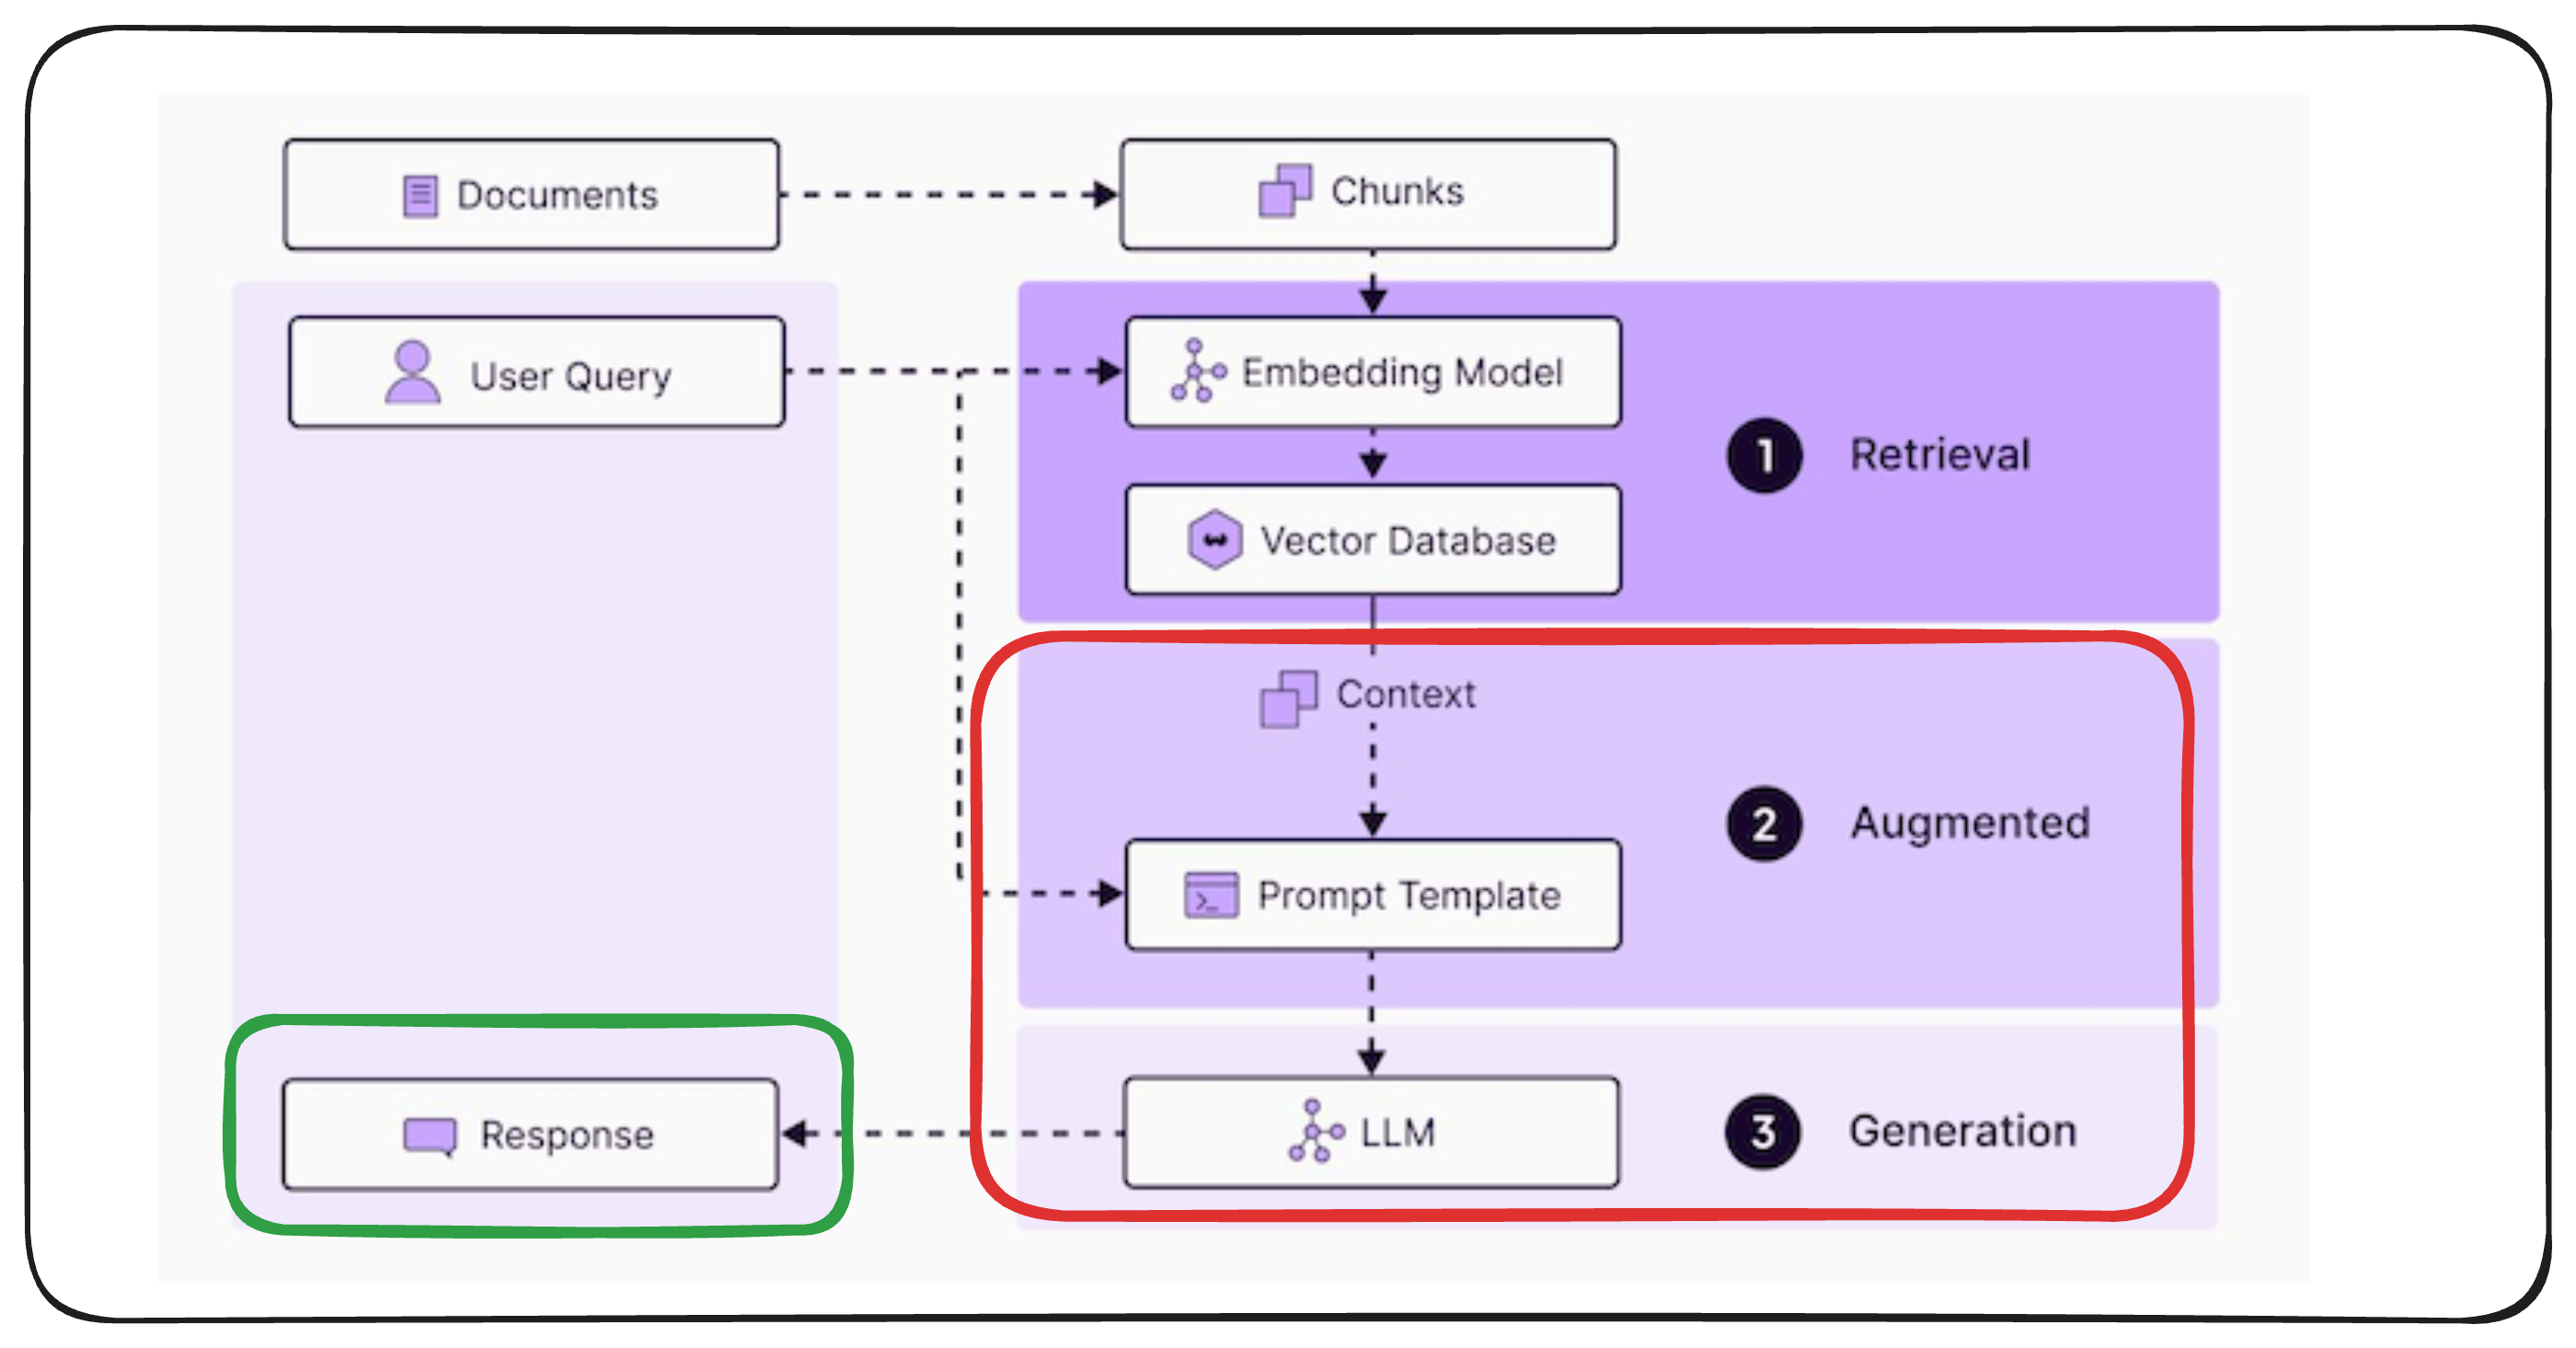

In [99]:
import google.generativeai as genai


def generate_answer(query, retrieved_results, client=None):
    """Generate an answer using retrieved documents and Gemini.

    Args:
        query: User's question
        retrieved_results: List of dicts with 'content' and 'score' keys
        client: Kept for signature compatibility (Gemini uses global config)
    """
    # Format retrieved documents exactly like before
    documents_text = "\n\n---\n\n".join([
        f"Document {i+1} (Relevance: {result['score']:.3f}):\n{result['content']}"
        for i, result in enumerate(retrieved_results)
    ])

    # Context and strict rules are passed directly via system_instruction
    system_instruction = """You are answering questions using ONLY information from the provided documents.

CRITICAL RULES:
1. Every fact in your answer MUST come directly from the provided documents.
2. If the documents don't contain enough information to answer the question, you MUST say so.
3. DO NOT use any knowledge from your training data.
4. DO NOT make inferences beyond what is explicitly stated.
5. DO NOT fill in gaps with plausible-sounding information."""

    prompt = f"""DOCUMENTS:
{documents_text}

QUESTION: {query}

Provide your answer following the rules above."""

    # Initialize Gemini model with instructions
    model = genai.GenerativeModel(
        model_name="gemini-2.5-flash", system_instruction=system_instruction
    )

    # Generate response deterministically
    response = model.generate_content(
        contents=prompt,
        generation_config={
            "temperature": 0.0,  # 0.0 forces strict adherence to documents
            "max_output_tokens": 500,
        },
    )

    return response.text


In [100]:
def complete_rag_pipeline(
    query,
    client,
    retriever,
    reranker,
    use_hyde=True,
    k_final=5
):
    """
    End-to-end RAG: Retrieve relevant documents and generate grounded answer.
    """
    print("=" * 80)
    print("COMPLETE RAG PIPELINE")
    print("=" * 80)
    print(f"Question: {query}\n")

    # Step 1: Retrieve and rerank documents
    print("Step 1: Retrieving relevant documents...")
    retrieved_results = production_retrieval_pipeline(
        query=query,
        client=client,
        retriever=retriever,
        reranker=reranker,
        use_hyde=use_hyde,
        k_final=k_final,
        verbose=False
    )
    print(f"Retrieved {len(retrieved_results)} relevant documents\n")

    # Step 2: Generate answer
    print("Step 2: Generating grounded answer...")
    answer = generate_answer(query, retrieved_results, client)

    print("\n" + "=" * 80)
    print("ANSWER")
    print("=" * 80)
    print(answer)

    print("\n" + "=" * 80)
    print("SOURCES")
    print("=" * 80)
    for i, result in enumerate(retrieved_results, 1):
        print(f"\nSource {i} (Relevance: {result['score']:.3f}):")
        print(f"{result['content'][:200]}...")

    return answer, retrieved_results

In [101]:
# Test the complete pipeline
question = "How do I load a pretrained model in Transformers?"

answer, sources = complete_rag_pipeline(
    query=question,
    client=client,
    retriever=retriever,
    reranker=reranker,
    use_hyde=True,
    k_final=3
)

COMPLETE RAG PIPELINE
Question: How do I load a pretrained model in Transformers?

Step 1: Retrieving relevant documents...
Retrieved 3 relevant documents

Step 2: Generating grounded answer...

ANSWER
To load a pretrained model in Transformers, you can use `AutoModelForZeroShotObjectDetection

SOURCES

Source 1 (Relevance: 4.857):
tasks/zero-sh-obj-detection_2.png" alt="Visualized predictions on NASA image"/>
</div>

## Text-prompted zero-shot object detection by hand

Now that you've seen how to use the zero-shot object detect...

Source 2 (Relevance: 4.857):
tasks/zero-sh-obj-detection_2.png" alt="Visualized predictions on NASA image"/>
</div>

## Text-prompted zero-shot object detection by hand

Now that you've seen how to use the zero-shot object detect...

Source 3 (Relevance: -2.151):
 dataset. This will yield some nice speedup on CPU and GPU. The downside is that all batches will then have different shapes, which slows down training on other accelerators like TPUs. Let's see ho

In [102]:
# Test with a question that might not be in the documents
question = "What is the weather in San Francisco?"

answer, sources = complete_rag_pipeline(
    query=question,
    client=client,
    retriever=retriever,
    reranker=reranker,
    use_hyde=False,
    k_final=3
)

COMPLETE RAG PIPELINE
Question: What is the weather in San Francisco?

Step 1: Retrieving relevant documents...
Retrieved 3 relevant documents

Step 2: Generating grounded answer...

ANSWER
The documents do not contain information about the weather in San Francisco.

SOURCES

Source 1 (Relevance: -11.003):
 warm in winter, that's another problem you'll have to deal with. 

In addition, as public awareness grows on climate and social responsibility issues, organizations need to account for their carbon f...

Source 2 (Relevance: -11.003):
 warm in winter, that's another problem you'll have to deal with. 

In addition, as public awareness grows on climate and social responsibility issues, organizations need to account for their carbon f...

Source 3 (Relevance: -11.091):
 score](https://huggingface.co/metrics/f1), which is the harmonic mean of the precision and recall. It also has a scale of 0.0 to 1.0.

Per type (e.g. `MISC`, `PER`, `LOC`,...):

`precision`: the aver...


In [103]:
!pip install -q gradio

In [104]:
import gradio as gr

def rag_interface(query, use_hyde, num_results):
    """
    Gradio interface for RAG system.
    """
    if not query.strip():
        return "Please enter a question.", ""

    try:
        # Run the RAG pipeline
        retrieved_results = production_retrieval_pipeline(
            query=query,
            client=client,
            retriever=retriever,
            reranker=reranker,
            use_hyde=use_hyde,
            k_final=num_results,
            verbose=False
        )

        # Generate answer
        answer = generate_answer(query, retrieved_results, client)

        # Format retrieved documents
        retrieved_docs_html = ""
        for i, result in enumerate(retrieved_results, 1):
            retrieved_docs_html += f"""
            <div style="border: 1px solid #ddd; padding: 15px; margin: 10px 0; border-radius: 5px; background-color: #f9f9f9;">
                <h4 style="color: #2c3e50; margin-top: 0;">📄 Document {i}</h4>
                <p style="color: #7f8c8d; font-size: 0.9em; margin: 5px 0;">
                    <strong>Relevance Score:</strong> {result['score']:.4f}
                </p>
                <p style="line-height: 1.6; color: #34495e;">
                    {result['content'][:400]}{'...' if len(result['content']) > 400 else ''}
                </p>
            </div>
            """

        # Format final answer
        answer_html = f"""
        <div style="border: 2px solid #3498db; padding: 20px; border-radius: 8px; background-color: #ecf0f1;">
            <h3 style="color: #2980b9; margin-top: 0;">💡 Answer</h3>
            <p style="line-height: 1.8; color: #2c3e50; font-size: 1.05em;">
                {answer}
            </p>
        </div>
        """

        return retrieved_docs_html, answer_html

    except Exception as e:
        error_msg = f"Error: {str(e)}"
        return error_msg, error_msg

# Create Gradio interface
with gr.Blocks(title="RAG System Demo", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🚀 Retrieval-Augmented Generation (RAG) System

    Ask questions about the Hugging Face documentation and get grounded, accurate answers!

    This system uses:
    - **HyDE** (optional): Generates hypothetical documents for better retrieval
    - **Bi-Encoder**: Fast HNSW-based vector search
    - **Cross-Encoder**: Precise reranking of candidates
    - **GPT-4**: Grounded generation using retrieved context
    """)

    with gr.Row():
        with gr.Column(scale=2):
            query_input = gr.Textbox(
                label="❓ Your Question",
                placeholder="e.g., How do I load a pretrained model?",
                lines=2
            )

            with gr.Row():
                hyde_checkbox = gr.Checkbox(
                    label="Enable HyDE (better for complex queries)",
                    value=True
                )
                num_results_slider = gr.Slider(
                    minimum=1,
                    maximum=5,
                    value=3,
                    step=1,
                    label="Number of source documents"
                )

            submit_btn = gr.Button("🔍 Search & Answer", variant="primary", size="lg")

    with gr.Row():
        with gr.Column():
            gr.Markdown("## 📚 Retrieved Documents")
            retrieved_output = gr.HTML(label="Source Documents")

    with gr.Row():
        with gr.Column():
            gr.Markdown("## 💬 Generated Answer")
            answer_output = gr.HTML(label="Final Answer")

    # Examples
    gr.Markdown("### 💡 Try these example questions:")
    gr.Examples(
        examples=[
            ["How do I load a pretrained model?", True, 3],
            ["What is tokenization?", True, 3],
            ["How do I fine-tune a transformer model?", True, 4],
            ["What are the different types of attention mechanisms?", False, 3],
        ],
        inputs=[query_input, hyde_checkbox, num_results_slider],
    )

    # Connect the button
    submit_btn.click(
        fn=rag_interface,
        inputs=[query_input, hyde_checkbox, num_results_slider],
        outputs=[retrieved_output, answer_output]
    )

    gr.Markdown("""
    ---
    ### 🎯 How it works:
    1. **Query Enhancement** (optional): HyDE generates a hypothetical answer to improve retrieval
    2. **Fast Retrieval**: Bi-encoder searches millions of documents using HNSW
    3. **Precise Reranking**: Cross-encoder deeply analyzes top candidates
    4. **Grounded Generation**: GPT generates answers using ONLY the retrieved documents
    """)

# Launch the app
demo.launch(share=True, debug=True)

/tmp/ipykernel_621/1290605770.py:57: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="RAG System Demo", theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://efe83d1741b6172cc2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://efe83d1741b6172cc2.gradio.live
